# Choosing k for KMeans clustering

Sweeps k over a NEMI ensemble and scores each k with four criteria from
`metrics.kmeans_eval`:

- **AIC / BIC** — from a GMM fitted to the member embedding at that k. Lower is
  better; BIC penalises k harder, so it favours fewer clusters.
- **SSE** — within-cluster sum of squares from the KMeans labels. Falls
  monotonically with k, so read the elbow rather than the minimum.
- **Silhouette** — cluster separation from the KMeans labels, in [-1, 1]. Higher
  is better, and unlike the other three it is not monotone in k, so its peak is
  directly meaningful.

The ensemble is built once (cuML UMAP, `assess_overlap=False`); every k is then
clustered with cuML KMeans on those same member embeddings, so member spread
reflects UMAP stochasticity and k values are compared pairwise across members.
Each panel plots the ensemble mean with the member min–max range shaded.

In [1]:
import llc_cutout_dataloader.cutouts_dataset as cutouts_dataset
import metrics.kmeans_eval as kmeans_eval
from nemi import NEMI, SingleNemi

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

/home/jovyan/conda_envs/main_cuml/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
source = cutouts_dataset.CutoutDataSource(bucket="dbof", folder="cutouts_dataset_v2",
                                          run_id="2_01",
                                          dataset_name="cutout_dataset.zarr",
                                          s3_endpoint="https://s3-west.nrp-nautilus.io"
                                          )

source.print_available_channels()

23 available channels:
['Eta','Salt','Theta','U','V','W','gradb2','oceTAUX','oceTAUY','gradrho2','turner_angle','strain_n','strain_s','strain_mag','divergence','relative_vorticity','coriolis_f','oceQnet','ekman_pumping','wind_stress_curl','SIarea','XC','YC']


In [3]:
#data_channels = ['Eta','Salt','Theta','U','V','W','gradb2','oceTAUX','oceTAUY','gradrho2','turner_angle','strain_n','strain_s','strain_mag','divergence','relative_vorticity','coriolis_f','oceQnet','ekman_pumping','wind_stress_curl']

data_channels_small = ['Eta','Salt','Theta','relative_vorticity','gradb2','oceQnet','wind_stress_curl']
#data_channels_engineered = ['gradb2','gradrho2','turner_angle','strain_n','strain_s','strain_mag','divergence','relative_vorticity','oceQnet','ekman_pumping','wind_stress_curl']
dataset = cutouts_dataset.CutoutDataset.from_source(data_channels=data_channels_small, source=source, subset=False,
                                                    subsample_per_chunk=64, num_sample_chunks=1, n_workers=4)

/home/jovyan/conda_envs/main_cuml/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 40733 instead
  warnings.warn(


<Client: 'tcp://127.0.0.1:36315' processes=4 threads=20, memory=200.00 GiB>
nrp link url : https://jupyterhub-west.nrp-nautilus.io/hub/user-redirect/proxy/40733/status
dropped 12 ice, 10 NaN; kept 29492 / 29511
features ['Eta', 'Salt', 'Theta', 'relative_vorticity', 'gradb2', 'oceQnet', 'wind_stress_curl'] | coords ['XC', 'YC']


2026-08-07 15:39:34,214 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2026-08-07 15:39:34,214 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2026-08-07 15:39:34,215 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2026-08-07 15:39:34,216 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing


In [4]:
patch_size = 8
patches = dataset.get_patches(patch_size=patch_size)   # (N_patches, C_feat*p*p), coords excluded

print(patches.shape)

(1887488, 448)


In [5]:
EMBEDDING_DIMENSIONS = 3
ENSEMBLE_MEMBERS = 2
K_VALUES = [50, 100, 500, 700]

UMAP_PARAMS = {"n_components": EMBEDDING_DIMENSIONS, "n_neighbors": 57, "min_dist": 0.0}

In [6]:
# One cuML UMAP per member; the k=K_VALUES[0] clustering here is discarded, the
# sweep re-clusters each member embedding at every k.
nemi = NEMI(params={
    "device": "gpu",
    "embedding_dict": UMAP_PARAMS,
    "clustering_dict": {"method": "kmeans", "n_clusters": K_VALUES[0]},
})
nemi.run(patches, n=ENSEMBLE_MEMBERS, assess_overlap=False)

embeddings = [member.embedding for member in nemi.nemi_pack]
print(f"{len(embeddings)} members | embedding {embeddings[0].shape}")

  0%|          | 0/2 [00:00<?, ?it/s]

[2026-08-07 15:35:29.520] [CUML] [warning] Spectral initialization failed, using random initialization instead.


 50%|█████     | 1/2 [01:25<01:25, 85.49s/it]

[2026-08-07 15:35:37.388] [CUML] [info] Building knn graph using nn descent


100%|██████████| 2/2 [01:48<00:00, 54.24s/it]


...

Clustering | device=gpu | {'method': 'kmeans', 'n_clusters': 50}


 50%|█████     | 1/2 [00:06<00:06,  6.41s/it]

Clusters found: 50
Clustering | device=gpu | {'method': 'kmeans', 'n_clusters': 50}


100%|██████████| 2/2 [00:10<00:00,  5.03s/it]

Clusters found: 50
2 members | embedding (1887488, 3)


In [12]:
def sweep_k(embeddings, k_values, device="gpu", seed=0):
    """Cluster every ensemble embedding at each k and score it.

    Returns a long DataFrame with one row per (member, k) and columns
    aic, bic, sse, silhouette.
    """
    rows = []
    for k in k_values:
        for member, embedding in enumerate(embeddings):
            # nm = SingleNemi(params={"device": device,
            #                         "clustering_dict": {"method": "kmeans", "n_clusters": k}})
            # nm.embedding = embedding
            # labels = nm.predict_clusters()
            print(f"Calculating aic and bic for {k}")
            bic, aic = kmeans_eval.bic_aic(embedding, k, random_state=seed)
            rows.append({"member": member, "k": k, "aic": aic, "bic": bic})
            print(f"done with {k}")


                         # "sse": kmeans_eval.sse(embedding, labels),
            #              "silhouette": kmeans_eval.silhouette(embedding, labels, seed=seed)
    return pd.DataFrame(rows)

In [13]:
scores = sweep_k(embeddings, K_VALUES)
scores.groupby("k").mean(numeric_only=True)

Calculating aic and bic for 50
done with 50
Calculating aic and bic for 50
done with 50
Calculating aic and bic for 100
done with 100
Calculating aic and bic for 100
done with 100
Calculating aic and bic for 500
done with 500
Calculating aic and bic for 500
done with 500
Calculating aic and bic for 700
done with 700
Calculating aic and bic for 700
done with 700


,member,aic,bic
k,,,
50,0.5,1.820058e+07,1.820679e+07
100,0.5,1.793506e+07,1.794750e+07
500,0.5,1.739157e+07,1.745381e+07
700,0.5,1.731402e+07,1.740117e+07


In [18]:
METRICS = ("aic", "bic") #, "sse", "silhouette")


def plot_k_metrics(scores, metrics=METRICS, panel_size=4):
    """One panel per metric: ensemble mean against k, member min-max range shaded."""
    fig, axes = plt.subplots(1, len(metrics), figsize=(panel_size * len(metrics), panel_size))
    axes = np.atleast_1d(axes)
    for ax, name in zip(axes, metrics):
        grouped = scores.groupby("k")[name]
        k = grouped.mean().index.to_numpy()
        ax.fill_between(k, grouped.min(), grouped.max(), alpha=0.2, label="member range")
        ax.plot(k, grouped.mean(), marker="o", label="ensemble mean")
        ax.set_xlabel("k")
        ax.set_ylabel(name)
        ax.set_title(name)
    axes[0].legend()
    fig.tight_layout()
    plt.show()

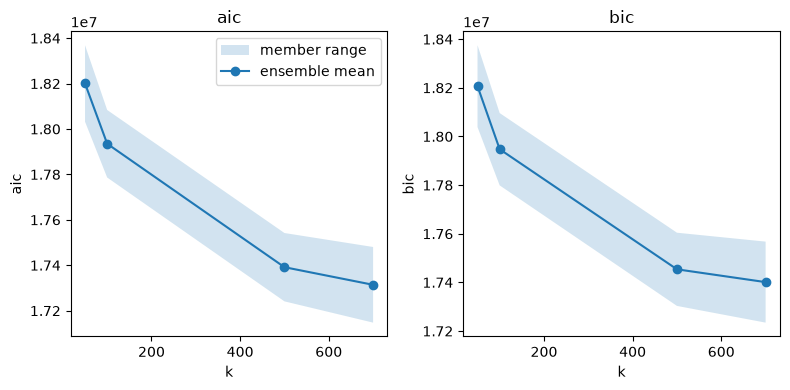

In [20]:
plot_k_metrics(scores)